<a href="https://colab.research.google.com/github/shikhachourey1992/Mateplotlib/blob/main/iris_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Iris.csv')
print(df)
print(df.columns)
print(df.isnull().sum())
print(df.drop('Id',axis=1))



      Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-setosa  
..              ...  
145  

In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


In [3]:

x=df.drop('Species',axis=1)
y=df['Species']
encoder=LabelEncoder()
y=encoder.fit_transform(y)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
model=GaussianNB()
model.fit(x_train,y_train)
prediction=model.predict(x_test)
print(prediction)




[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [4]:

comparesion=pd.DataFrame({'Actual':y_test,'Predicted':prediction})
print(comparesion.head(10))

   Actual  Predicted
0       1          1
1       0          0
2       2          2
3       1          1
4       1          1
5       0          0
6       1          1
7       2          2
8       1          1
9       1          1


In [5]:
ac=accuracy_score(y_test,prediction)
print(ac)

1.0


In [6]:
cm=confusion_matrix(y_test,prediction)
print(cm)

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [8]:
classfiction=classification_report(y_test,prediction,target_names=encoder.classes_)
print(classfiction)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



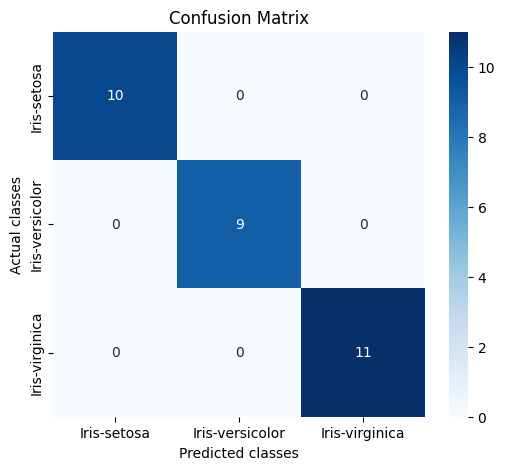

In [16]:
plt.figure(figsize=(6,5))


sns.heatmap(cm,annot=True,fmt='g',cmap='Blues',xticklabels=encoder.classes_,
    yticklabels=encoder.classes_)
plt.xlabel('Predicted classes')
plt.ylabel('Actual classes')
plt.title('Confusion Matrix')
plt.show()

In [11]:
new_flower=[[5.1,3.5,1.4,0.2,1.5]]
new_data=model.predict(new_flower)
print(new_data)
flower=encoder.inverse_transform(new_data)
print(flower[0])

[1]
Iris-versicolor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [17]:

flowers = [

    [5.1,3.5,1.4,0.2,2.1],

    [6.2,2.9,4.3,1.3,3.1],

    [7.3,2.9,6.3,1.8,0.8]

]
prediction=model.predict(flowers)
names=encoder.inverse_transform(prediction)
print('multiple prediction')
for i in range (len (flowers)):
  print(flowers[i],'-->',names[i])



multiple prediction
[5.1, 3.5, 1.4, 0.2, 2.1] --> Iris-versicolor
[6.2, 2.9, 4.3, 1.3, 3.1] --> Iris-versicolor
[7.3, 2.9, 6.3, 1.8, 0.8] --> Iris-setosa


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [19]:
#prediction probabilities
print(model.predict_proba(new_flower))

[[3.86110030e-21 1.00000000e+00 8.86424051e-19]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [23]:
prediction_for_result = model.predict(x_test)
result=x_test.copy()
result['Actual']=encoder.inverse_transform(y_test)
result["Predicted"] = encoder.inverse_transform(prediction_for_result)

result.to_csv("Prediction_Result.csv", index=False)